<a href="https://colab.research.google.com/github/AROO-6/Thiranex_task/blob/main/Thiranex_4_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Most are pre-installed in Colab; statsmodels may need installing
!pip install statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
np.random.seed(42)
n = 48000
dates = pd.date_range('2021-01-01', '2023-12-31', periods=n)

df = pd.DataFrame({
    'date': dates,
    'order_id': range(n),
    'customer_id': np.random.randint(1, 12841, n),
    'category': np.random.choice(['Electronics','Apparel','Home & Kitchen','Sports','Beauty'],
                                  n, p=[0.28,0.23,0.19,0.16,0.14]),
    'revenue': np.abs(np.random.normal(173, 90, n)),
    'quantity': np.random.randint(1, 6, n),
    'discount_pct': np.random.uniform(0, 0.4, n),
    'returned': np.random.choice([0, 1], n, p=[0.918, 0.082])
})

df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')
df['year'] = df['date'].dt.year
df['dow'] = df['date'].dt.day_name()
print(df.shape)
df.head()

(48000, 11)


,date,order_id,customer_id,category,revenue,quantity,discount_pct,returned,month,year,dow
0,2021-01-01 00:00:00.000000000,0,7271,Beauty,245.629477,4,0.308614,0,2021-01,2021,Friday
1,2021-01-01 00:32:49.241025854,1,861,Apparel,121.655883,3,0.395134,0,2021-01,2021,Friday
2,2021-01-01 01:05:38.482051709,2,5391,Sports,254.726529,4,0.201782,0,2021-01,2021,Friday
3,2021-01-01 01:38:27.723077564,3,5192,Home & Kitchen,76.112230,5,0.175878,0,2021-01,2021,Friday
4,2021-01-01 02:11:16.964103418,4,11965,Sports,352.529499,5,0.124311,0,2021-01,2021,Friday


                                date      order_id   customer_id  \
count                          48000  48000.000000  48000.000000   
mean   2022-07-01 23:59:59.999999744  23999.500000   6429.511854   
min              2021-01-01 00:00:00      0.000000      1.000000   
25%              2021-10-01 12:00:00  11999.750000   3207.000000   
50%              2022-07-02 00:00:00  23999.500000   6439.500000   
75%              2023-04-01 12:00:00  35999.250000   9666.000000   
max              2023-12-31 00:00:00  47999.000000  12840.000000   
std                              NaN  13856.550797   3713.621138   

            revenue      quantity  discount_pct      returned          year  
count  48000.000000  48000.000000  48000.000000  48000.000000  48000.000000  
mean     175.144468      3.002792      0.200389      0.083375   2021.999083  
min        0.013293      1.000000      0.000014      0.000000   2021.000000  
25%      113.238626      2.000000      0.099791      0.000000   2021.000000

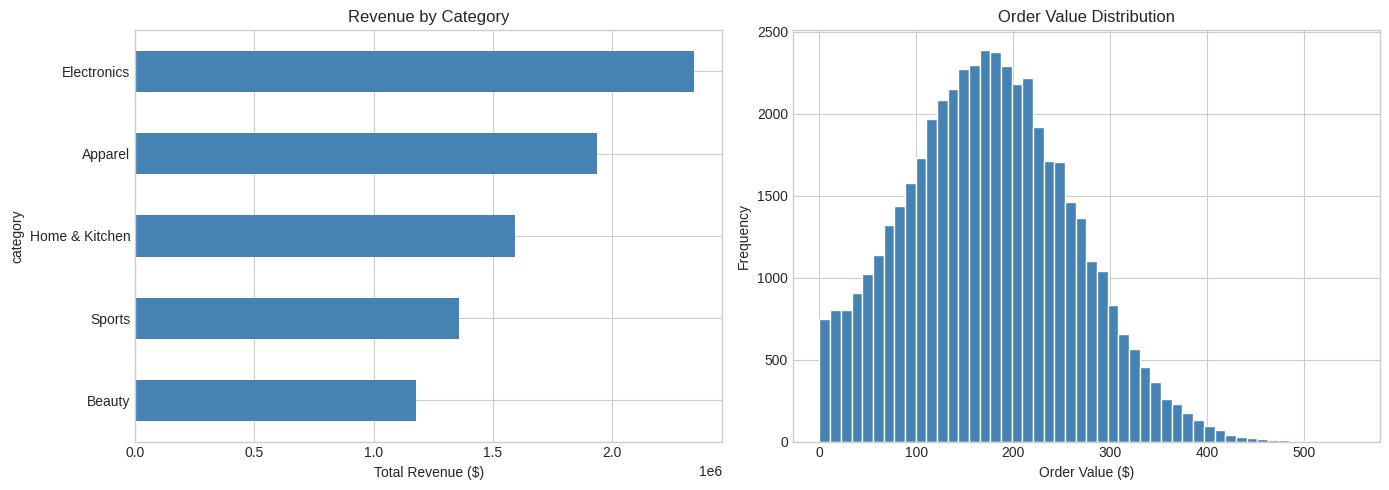

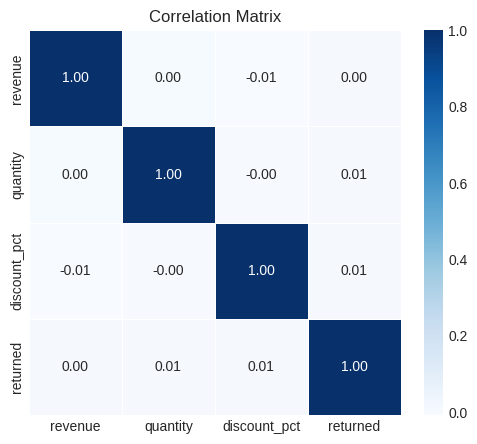

In [4]:
# Summary stats
print(df.describe())
print("\nRevenue by Category:")
print(df.groupby('category')['revenue'].sum().sort_values(ascending=False))

# Plot revenue by category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_rev = df.groupby('category')['revenue'].sum().sort_values()
cat_rev.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Revenue by Category')
axes[0].set_xlabel('Total Revenue ($)')

df['revenue'].plot(kind='hist', bins=50, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Order Value Distribution')
axes[1].set_xlabel('Order Value ($)')

plt.tight_layout()
plt.show()

# Correlation heatmap
corr_df = df[['revenue','quantity','discount_pct','returned']].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

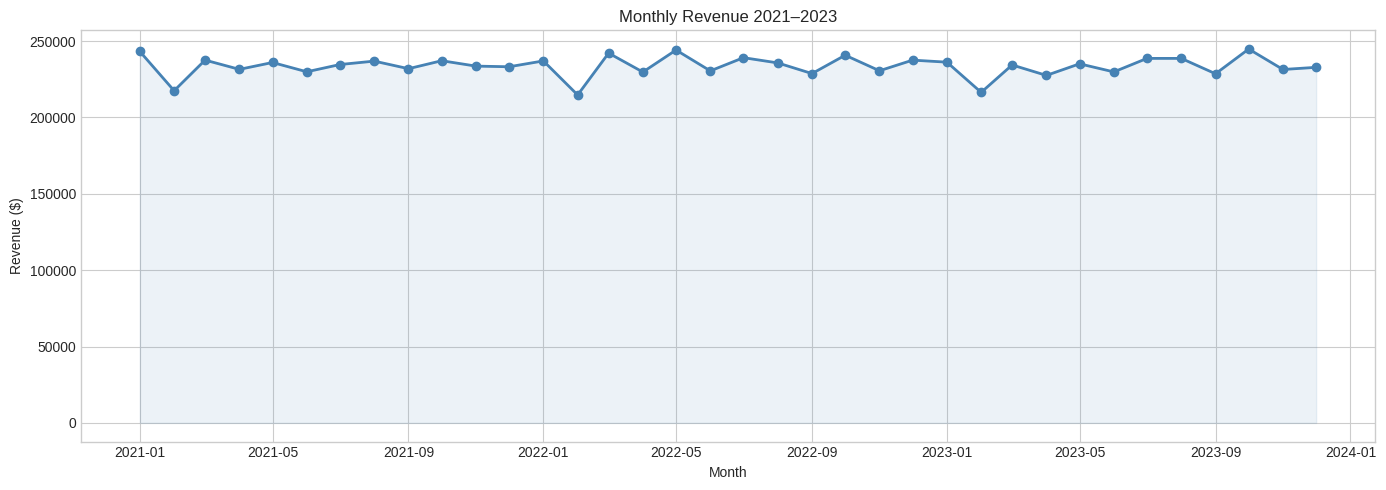

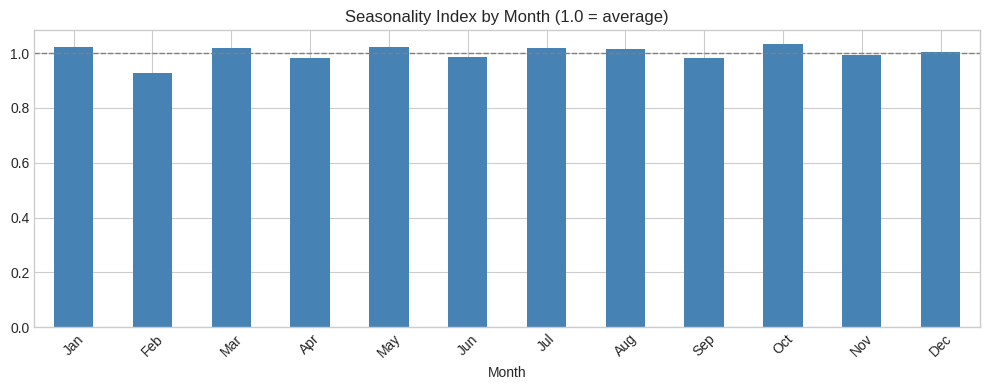

In [5]:
monthly = df.groupby('month')['revenue'].sum().reset_index()
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

plt.figure(figsize=(14, 5))
plt.plot(monthly['month_dt'], monthly['revenue'], marker='o', linewidth=2, color='steelblue')
plt.fill_between(monthly['month_dt'], monthly['revenue'], alpha=0.1, color='steelblue')
plt.title('Monthly Revenue 2021–2023')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

# Seasonality index
monthly['month_num'] = monthly['month_dt'].dt.month
overall_mean = monthly['revenue'].mean()
season_idx = monthly.groupby('month_num')['revenue'].mean() / overall_mean

plt.figure(figsize=(10, 4))
season_idx.plot(kind='bar', color=['#D85A30' if v > 1.1 else 'steelblue' for v in season_idx])
plt.axhline(1.0, linestyle='--', color='gray', linewidth=1)
plt.title('Seasonality Index by Month (1.0 = average)')
plt.xlabel('Month')
plt.xticks(ticks=range(12),
           labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
           rotation=45)
plt.tight_layout()
plt.show()

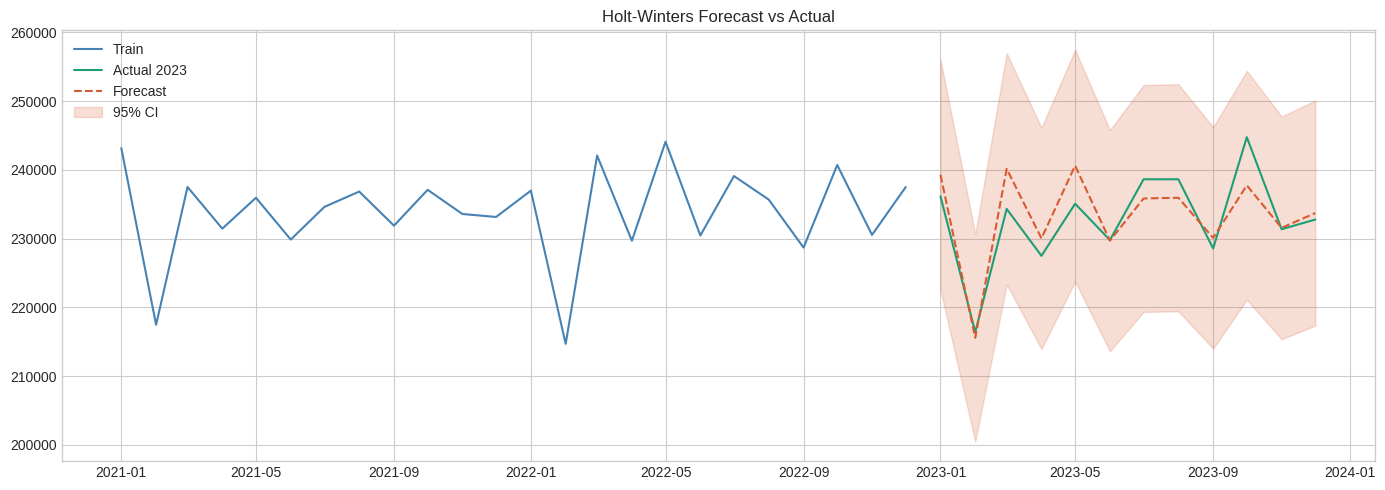

Validation MAPE: 1.17%


In [6]:
monthly_series = monthly.set_index('month_dt')['revenue']

# Train on 2021–2022, validate on 2023
train = monthly_series[:'2022-12']
test  = monthly_series['2023-01':]

model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12)
fit = model.fit()
forecast = fit.forecast(12)

plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label='Train', color='steelblue')
plt.plot(test.index, test, label='Actual 2023', color='#1D9E75')
plt.plot(test.index, forecast, label='Forecast', color='#D85A30', linestyle='--')
plt.fill_between(test.index,
                 forecast * 0.93, forecast * 1.07,
                 alpha=0.2, color='#D85A30', label='95% CI')
plt.title('Holt-Winters Forecast vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

# MAPE
mape = np.mean(np.abs((test.values - forecast.values) / test.values)) * 100
print(f'Validation MAPE: {mape:.2f}%')

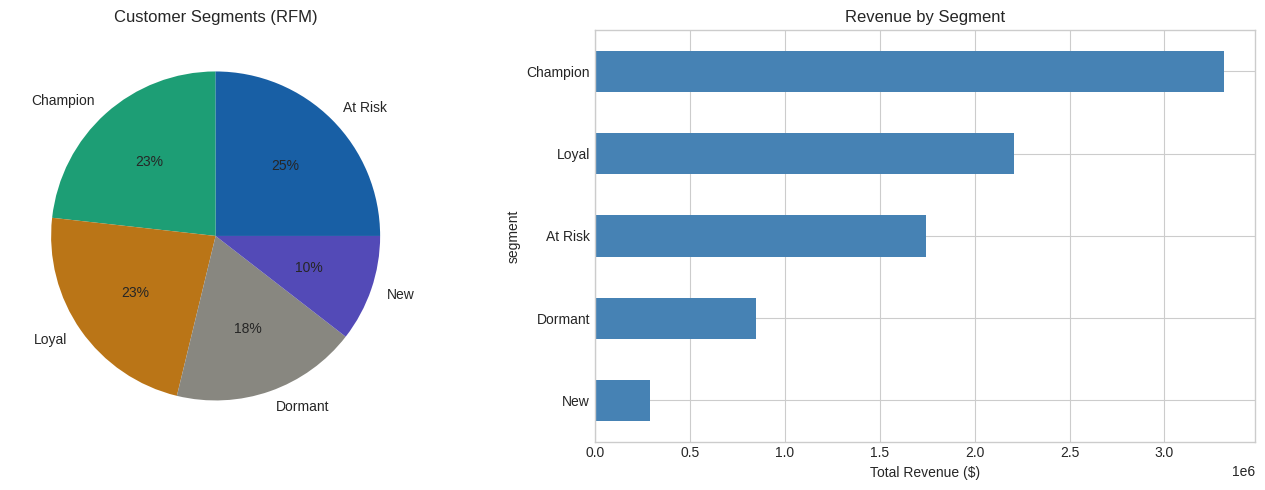

          recency  frequency  monetary
segment                               
At Risk     253.9        3.2     555.4
Champion    103.0        6.3    1138.4
Dormant     388.7        2.3     371.2
Loyal       157.2        4.3     767.1
New         678.8        1.4     220.3


In [7]:
snapshot_date = df['date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    recency  = ('date', lambda x: (snapshot_date - x.max()).days),
    frequency= ('order_id', 'count'),
    monetary = ('revenue', 'sum')
).reset_index()

# Score each dimension 1–4
for col in ['recency','frequency','monetary']:
    if col == 'recency':
        rfm[f'{col}_score'] = pd.qcut(rfm[col], 4, labels=[4,3,2,1])
    else:
        rfm[f'{col}_score'] = pd.qcut(rfm[col], 4, labels=[1,2,3,4])

rfm['rfm_score'] = (rfm['recency_score'].astype(int)
                  + rfm['frequency_score'].astype(int)
                  + rfm['monetary_score'].astype(int))

# Label segments
def label_segment(score):
    if score >= 10: return 'Champion'
    elif score >= 8: return 'Loyal'
    elif score >= 6: return 'At Risk'
    elif score >= 4: return 'Dormant'
    else: return 'New'

rfm['segment'] = rfm['rfm_score'].apply(label_segment)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rfm['segment'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.0f%%',
    colors=['#185FA5','#1D9E75','#BA7517','#888780','#534AB7'])
axes[0].set_title('Customer Segments (RFM)')
axes[0].set_ylabel('')

seg_rev = df.merge(rfm[['customer_id','segment']], on='customer_id')
seg_rev.groupby('segment')['revenue'].sum().sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Revenue by Segment')
axes[1].set_xlabel('Total Revenue ($)')

plt.tight_layout()
plt.show()

print(rfm.groupby('segment')[['recency','frequency','monetary']].mean().round(1))

In [8]:
# Save processed data and RFM table
df.to_csv('retail_data_clean.csv', index=False)
rfm.to_csv('rfm_segments.csv', index=False)

# Download to your machine
from google.colab import files
files.download('rfm_segments.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>